In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- Load data ---
testdata2 = "GCZ2025_1Aug-13Nov2025.xlsx"
testdata1 = "GCG2026_1Dec2025-9Jan2026.xlsx"
df1 = pd.read_excel(testdata1)
df2 = pd.read_excel(testdata2)

# --- verify columns match ---
assert list(df1.columns) == list(df2.columns), "Column mismatch between files!"

# --- Combine (append rows) ---
combined_df = pd.concat([df1, df2], ignore_index=True)

In [3]:
# --- Load no overlap data ---
testdata2_noov = "GCZ2025_1Aug-13Nov2025_nooverlap.xlsx"
testdata1_noov = "GCG2026_1Dec2025-9Jan2026_nooverlap.xlsx"
df1_noov = pd.read_excel(testdata1_noov)
df2_noov = pd.read_excel(testdata2_noov)

# --- verify columns match ---
assert list(df1_noov.columns) == list(df2_noov.columns), "Column mismatch between files!"

# --- Combine (append rows) ---
combined_df_noov = pd.concat([df1_noov, df2_noov], ignore_index=True)


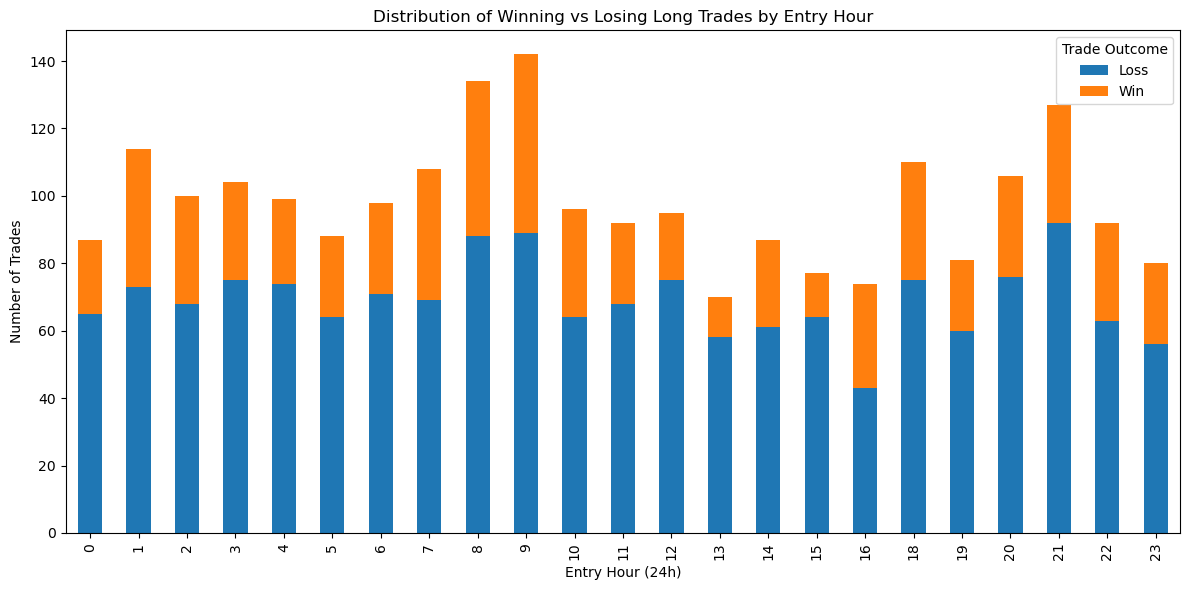

In [4]:
# --- Filter for long entries only ---
df_long = combined_df[combined_df["Type"] == "Entry long"].copy()

# --- Ensure entry time is datetime ---
df_long["entry_time"] = pd.to_datetime(df_long["Date and time"])

# --- Extract hour of day ---
df_long["hour"] = df_long["entry_time"].dt.hour

# --- Classify win vs loss ---
df_long["result"] = df_long["Net P&L USD"].apply(lambda x: "Win" if x > 0 else "Loss")

# --- Aggregate counts by hour and result ---
distribution = (
    df_long
    .groupby(["hour", "result"])
    .size()
    .unstack(fill_value=0)
)

# --- Plot stacked bar chart ---
distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribution of Winning vs Losing Long Trades by Entry Hour")
plt.xlabel("Entry Hour (24h)")
plt.ylabel("Number of Trades")
plt.legend(title="Trade Outcome")
plt.tight_layout()
plt.show()


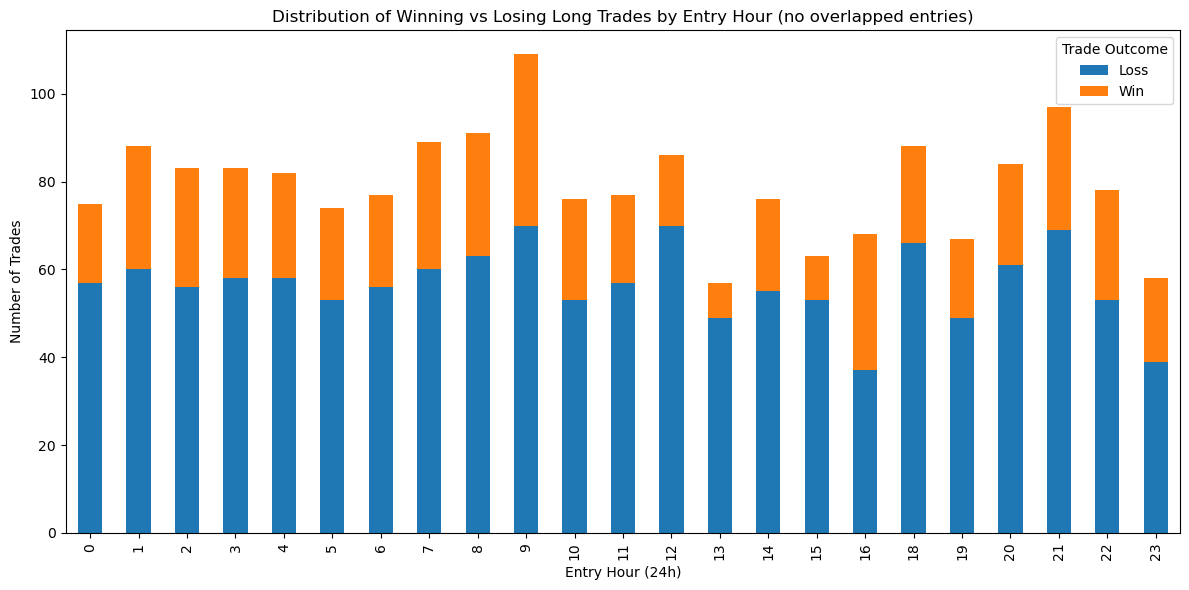

In [5]:
# --- Create the same distribution graph for "no overlap" entries ---

# --- Filter for long entries only ---
df_long_noov = combined_df_noov[combined_df_noov["Type"] == "Entry long"].copy()

# --- Ensure entry time is datetime ---
df_long_noov["entry_time"] = pd.to_datetime(df_long_noov["Date and time"])

# --- Extract hour of day ---
df_long_noov["hour"] = df_long_noov["entry_time"].dt.hour

# --- Classify win vs loss ---
df_long_noov["result"] = df_long_noov["Net P&L USD"].apply(lambda x: "Win" if x > 0 else "Loss")

# --- Aggregate counts by hour and result ---
distribution_noov = (
    df_long_noov
    .groupby(["hour", "result"])
    .size()
    .unstack(fill_value=0)
)

# --- Plot stacked bar chart ---
distribution_noov.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribution of Winning vs Losing Long Trades by Entry Hour (no overlapped entries)")
plt.xlabel("Entry Hour (24h)")
plt.ylabel("Number of Trades")
plt.legend(title="Trade Outcome")
plt.tight_layout()
plt.show()

In [24]:
# --- save all test data in one combined file ---
# output_path = "all_testdata.xlsx"
# combined_df.to_excel(output_path, index=False)

In [26]:
df_long.head(5)

,Trade #,Type,Date and time,Signal,Price USD,Position size (qty),Position size (value),Net P&L USD,Net P&L %,Favorable excursion USD,Favorable excursion %,Adverse excursion USD,Adverse excursion %,Cumulative P&L USD,Cumulative P&L %,entry_time,hour,result
1,1,Entry long,2025-11-30 19:15,Entry Area,4258.3,2,851660,-720,-0.08,300,0.04,-720,-0.08,-720,-0.07,2025-11-30 19:15:00,19,Loss
3,2,Entry long,2025-11-30 19:47,Entry Area,4265.8,2,853160,-640,-0.08,40,0.00,-640,-0.08,-1360,-0.14,2025-11-30 19:47:00,19,Loss
5,3,Entry long,2025-11-30 20:08,Entry Area,4258.1,2,851620,2300,0.27,2300,0.27,-640,-0.08,940,0.09,2025-11-30 20:08:00,20,Win
7,4,Entry long,2025-11-30 22:15,Entry Area,4267.9,2,853580,1600,0.19,1600,0.19,-120,-0.01,2540,0.25,2025-11-30 22:15:00,22,Win
9,5,Entry long,2025-11-30 23:48,Entry Area,4278.5,2,855700,-620,-0.07,680,0.08,-620,-0.07,1920,0.19,2025-11-30 23:48:00,23,Loss


In [6]:
# --- look at the trades between 7-9am ET ---
# df_long.iloc[:,2].head()
df_long["Date and time"] = pd.to_datetime(df_long.iloc[:,2])
df_long_noov["Date and time"] = pd.to_datetime(df_long_noov.iloc[:,2])


In [7]:
df_trades789 = df_long[
    (df_long.iloc[:, 1] == "Entry long") &
    (df_long["hour"].isin([7, 8, 9]))
]

df_trades789_noov = df_long_noov[
    (df_long_noov.iloc[:, 1] == "Entry long") &
    (df_long_noov["hour"].isin([7, 8, 9]))
]

# df_trades789.head()
df_trades789_noov.head()

,Trade #,Type,Date and time,Signal,Price USD,Position size (qty),Position size (value),Net P&L USD,Net P&L %,Favorable excursion USD,Favorable excursion %,Adverse excursion USD,Adverse excursion %,Cumulative P&L USD,Cumulative P&L %,entry_time,hour,result
19,10,Entry long,2025-12-01 07:41:00,Entry Area,4288.2,2,857640,-460,-0.05,280,0.03,-460,-0.05,5040,0.50,2025-12-01 07:41:00,7,Loss
21,11,Entry long,2025-12-01 08:49:00,Entry Area,4292.5,2,858500,120,0.01,180,0.02,0,0.00,5160,0.52,2025-12-01 08:49:00,8,Win
23,12,Entry long,2025-12-01 09:38:00,Entry Area,4259.8,2,851960,320,0.04,1400,0.16,-40,0.00,5480,0.55,2025-12-01 09:38:00,9,Win
55,28,Entry long,2025-12-02 07:06:00,Entry Area,4237.3,2,847460,-540,-0.06,200,0.02,-540,-0.06,2220,0.22,2025-12-02 07:06:00,7,Loss
57,29,Entry long,2025-12-02 08:09:00,Entry Area,4237.6,2,847520,-320,-0.04,0,0.00,-540,-0.06,1900,0.19,2025-12-02 08:09:00,8,Loss


In [8]:
# --- normalize PnL 1250 and -500 ---
df_trades789_normPnL = df_trades789.copy()
df_trades789_normPnL.iloc[:,7] = np.where(
    df_trades789.iloc[:,7] > 0,
    1250, # winning trade 2.5RR
    -500 # losing trade
)

df_trades789_normPnL_noov = df_trades789_noov.copy()
df_trades789_normPnL_noov.iloc[:,7] = np.where(
    df_trades789_noov.iloc[:,7] > 0,
    1250, # winning trade 2.5RR
    -500 # losing trade
)


df_trades789_normPnL_noov.head(20)

,Trade #,Type,Date and time,Signal,Price USD,Position size (qty),Position size (value),Net P&L USD,Net P&L %,Favorable excursion USD,Favorable excursion %,Adverse excursion USD,Adverse excursion %,Cumulative P&L USD,Cumulative P&L %,entry_time,hour,result
19,10,Entry long,2025-12-01 07:41:00,Entry Area,4288.2,2,857640,-500,-0.05,280,0.03,-460,-0.05,5040,0.50,2025-12-01 07:41:00,7,Loss
21,11,Entry long,2025-12-01 08:49:00,Entry Area,4292.5,2,858500,1250,0.01,180,0.02,0,0.00,5160,0.52,2025-12-01 08:49:00,8,Win
23,12,Entry long,2025-12-01 09:38:00,Entry Area,4259.8,2,851960,1250,0.04,1400,0.16,-40,0.00,5480,0.55,2025-12-01 09:38:00,9,Win
55,28,Entry long,2025-12-02 07:06:00,Entry Area,4237.3,2,847460,-500,-0.06,200,0.02,-540,-0.06,2220,0.22,2025-12-02 07:06:00,7,Loss
57,29,Entry long,2025-12-02 08:09:00,Entry Area,4237.6,2,847520,-500,-0.04,0,0.00,-540,-0.06,1900,0.19,2025-12-02 08:09:00,8,Loss
59,30,Entry long,2025-12-02 08:11:00,Entry Area,4236.7,2,847340,-500,-0.04,0,0.00,-340,-0.04,1560,0.16,2025-12-02 08:11:00,8,Loss
61,31,Entry long,2025-12-02 08:44:00,Entry Area,4237.8,2,847560,-500,-0.09,0,0.00,-780,-0.09,780,0.08,2025-12-02 08:44:00,8,Loss
63,32,Entry long,2025-12-02 09:30:00,Entry Area,4256.9,2,851380,-500,-0.08,920,0.11,-680,-0.08,100,0.01,2025-12-02 09:30:00,9,Loss
65,33,Entry long,2025-12-02 09:43:00,Entry Area,4248.7,2,849740,1250,0.17,1460,0.17,-520,-0.06,1560,0.16,2025-12-02 09:43:00,9,Win
101,51,Entry long,2025-12-03 07:21:00,Entry Area,4235.6,2,847120,1250,0.14,1180,0.14,-80,-0.01,-1420,-0.14,2025-12-03 07:21:00,7,Win


In [9]:
wins = (df_trades789_normPnL.iloc[:, 7] > 0).sum()
losses = (df_trades789_normPnL.iloc[:, 7] <= 0).sum()

wins_noov = (df_trades789_normPnL_noov.iloc[:, 7] > 0).sum()
losses_noov = (df_trades789_normPnL_noov.iloc[:, 7] <= 0).sum()

print("wins ", wins, "losses ", losses)
print("wins no overlap ", wins_noov, "losses no overlap ", losses_noov)

wins  138 losses  246
wins no overlap  96 losses no overlap  193


In [10]:
win_rate = wins / (wins + losses)
print("win rate ", win_rate)

win_rate_noov = wins_noov / (wins_noov + losses_noov)
print("win rate no overlap", win_rate_noov)

win rate  0.359375
win rate no overlap 0.33217993079584773


In [11]:
print("total P/L ", sum(df_trades789_normPnL.iloc[:, 7]))

print("total P/L no overlap ", sum(df_trades789_normPnL_noov.iloc[:, 7]))


total P/L  49500
total P/L no overlap  23500


In [54]:
# --- Python Code: Cumulative P&L + Trailing Drawdown (Same Plot) ---

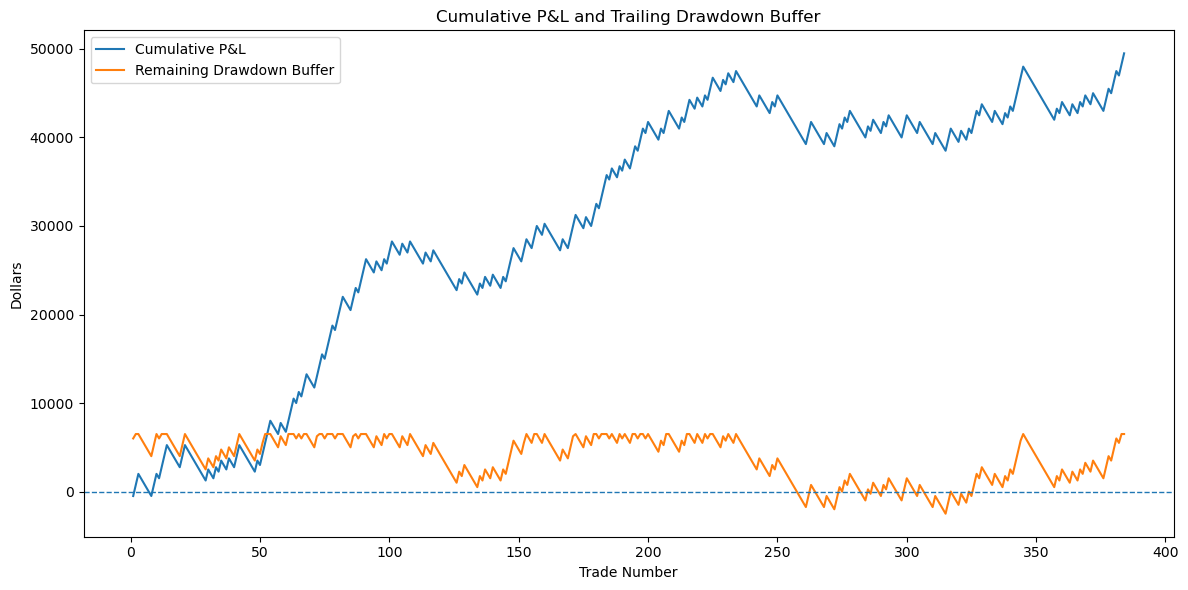

In [57]:

# --- P&L column (Column H) ---
pnl = df_trades789_normPnL.iloc[:, 7].reset_index(drop=True)

# --- Trade numbers ---
trade_number = range(1, len(pnl) + 1)

# --- Cumulative P&L ---
cum_pnl = pnl.cumsum()

# --- Trailing drawdown buffer logic ---
starting_dd = 6500
dd_buffer = []

current_dd = starting_dd

for trade_pnl in pnl:
    current_dd += trade_pnl          # add win or loss
    current_dd = min(current_dd, starting_dd)  # cap at 6500
    dd_buffer.append(current_dd)

dd_buffer = pd.Series(dd_buffer)

# --- Plot ---
plt.figure(figsize=(12, 6))

plt.plot(trade_number, cum_pnl, label="Cumulative P&L")
plt.plot(trade_number, dd_buffer, label="Remaining Drawdown Buffer")

plt.axhline(0, linestyle="--", linewidth=1)  # failure line

plt.xlabel("Trade Number")
plt.ylabel("Dollars")
plt.title("Cumulative P&L and Trailing Drawdown Buffer")
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
# --- lowest value of draw down ---
dd_buffer.min()

-2500

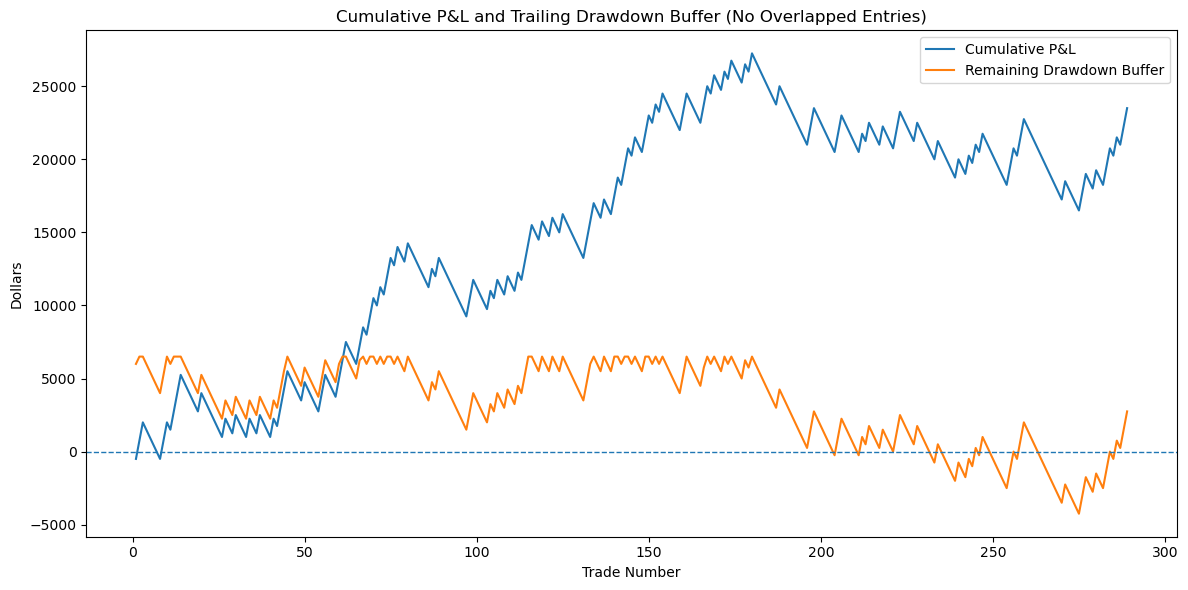

In [12]:
# --- P&L column (Column H) ---
pnl_noov = df_trades789_normPnL_noov.iloc[:, 7].reset_index(drop=True)

# --- Trade numbers ---
trade_number_noov = range(1, len(pnl_noov) + 1)

# --- Cumulative P&L ---
cum_pnl_noov = pnl_noov.cumsum()

# --- Trailing drawdown buffer logic ---
starting_dd = 6500
dd_buffer = []

current_dd = starting_dd

for trade_pnl in pnl_noov:
    current_dd += trade_pnl          # add win or loss
    current_dd = min(current_dd, starting_dd)  # cap at 6500
    dd_buffer.append(current_dd)

dd_buffer = pd.Series(dd_buffer)

# --- Plot ---
plt.figure(figsize=(12, 6))

plt.plot(trade_number_noov, cum_pnl_noov, label="Cumulative P&L")
plt.plot(trade_number_noov, dd_buffer, label="Remaining Drawdown Buffer")

plt.axhline(0, linestyle="--", linewidth=1)  # failure line

plt.xlabel("Trade Number")
plt.ylabel("Dollars")
plt.title("Cumulative P&L and Trailing Drawdown Buffer (No Overlapped Entries)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# --- lowest value of draw down ---
dd_buffer.min()

-4250